I am to lazy to predict the test, but it should work anyway

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style='whitegrid', context='notebook', palette='Set2')
sns.despine()
# get train & test csv files as a DataFrame
train = pd.read_csv("../input/train.csv")
test = pd.read_csv("../input/test.csv")
print("train matrix shape:",train.shape)
train['split']=0
test['split']=1
# combine train and test set
traint = train.append(test)
traint = traint.set_index('PassengerId')
print("test matrix shape:",test.shape)
print("combined in train matrix shape:",traint.shape)


train matrix shape: (891, 12)
test matrix shape: (418, 12)
combined in train matrix shape: (1309, 12)


In [2]:
#Data cleanup
#Cabin First letter
traint['CabinLet']=traint['Cabin'].str[:1]
traint['AgeDec']=traint['Age']/10
traint['AgeDec']=traint['AgeDec'].round(0)
traint['FareDec']=np.log(traint['Fare']+1)
traint['FareDec']=traint['FareDec'].round(0)
traint=traint.sort_values(['Fare'])
traint['CabinLet']=traint['CabinLet'].fillna(method='bfill')
traint['AgeDec']=traint['AgeDec'].fillna(method='bfill')
print(traint)

              Age            Cabin Embarked      Fare  \
PassengerId                                             
733           NaN              NaN        S    0.0000   
414           NaN              NaN        S    0.0000   
807          39.0              A36        S    0.0000   
1158          NaN              NaN        S    0.0000   
634           NaN              NaN        S    0.0000   
675           NaN              NaN        S    0.0000   
816           NaN             B102        S    0.0000   
1264         49.0      B52 B54 B56        S    0.0000   
467           NaN              NaN        S    0.0000   
598          49.0              NaN        S    0.0000   
264          40.0              B94        S    0.0000   
303          19.0              NaN        S    0.0000   
482           NaN              NaN        S    0.0000   
278           NaN              NaN        S    0.0000   
272          25.0              NaN        S    0.0000   
180          36.0              

In [3]:
from collections import Counter

def detect_outliers(df,n,features):
    # Categorical features
    cat_cols = []
    for c in df.columns:
        if df[c].dtype == 'object':
            cat_cols.append(c)
    print('Categorical columns:', cat_cols)

    # Dublicate features
    d = {}; done = []
    cols = df.columns.values
    for c in cols:
        d[c]=[]
    for i in range(len(cols)):
        if i not in done:
            for j in range(i+1, len(cols)):
                if all(df[cols[i]] == df[cols[j]]):
                    done.append(j)
                    d[cols[i]].append(cols[j])
    dub_cols = []
    for k in d.keys():
        if len(d[k]) > 0: 
            # print k, d[k]
            dub_cols += d[k]        
    print('Dublicates:', dub_cols)

    
    # Constant columns
    const_cols = []
    for c in cols:
        if len(df[c].unique()) == 1:
            const_cols.append(c)
    print('Constant cols:', const_cols)

    # Outlier detection     
    """
    Takes a dataframe df of features and returns a list of the indices
    corresponding to the observations containing more than n outliers according
    to the Tukey method.
    """
    outlier_indices = []
    
    # iterate over features(columns)
    for col in features:
        # 1st quartile (25%)
        Q1 = np.percentile(df[col], 25)
        # 3rd quartile (75%)
        Q3 = np.percentile(df[col],75)
        # Interquartile range (IQR)
        IQR = Q3 - Q1
        
        # outlier step
        outlier_step = 1.5 * IQR
        
        # Determine a list of indices of outliers for feature col
        outlier_list_col = df[(df[col] < Q1 - outlier_step) | (df[col] > Q3 + outlier_step )].index
        
        # append the found outlier indices for col to the list of outlier indices 
        outlier_indices.extend(outlier_list_col)
        
    # select observations containing more than 2 outliers
    outlier_indices = Counter(outlier_indices)        
    multiple_outliers = list( k for k, v in outlier_indices.items() if v > n )
    
    return multiple_outliers   

# detect outliers from Age, SibSp , Parch and Fare
Outliers_to_drop = detect_outliers(traint,2,['Age','SibSp','Parch','Fare','FareDec','AgeDec'])
traint.loc[Outliers_to_drop] # Show the outliers rows
const_cols=[]
dub_cols=[]

Categorical columns: ['Cabin', 'Embarked', 'Name', 'Sex', 'Ticket', 'CabinLet']
Dublicates: []
Constant cols: []


/opt/conda/lib/python3.6/site-packages/numpy/lib/function_base.py:4269: RuntimeWarning: Invalid value encountered in percentile
  interpolation=interpolation)


Instead of labelencoding lets TFIDF all tekst and cluster it...

In [4]:
if traint['Name'].isnull().values.sum()==0:
    traint['tekst']=traint['Name']
if traint['Ticket'].isnull().values.sum()==0:
    traint['tekst']=traint['tekst']+' T'+traint['Ticket']
if traint['Sex'].isnull().values.sum()==0:
    traint['tekst']=traint['tekst']+' '+traint['Sex']
if traint['Embarked'].isnull().values.sum()==0:
    traint['tekst']=traint['tekst']+' '+traint['Embarked']
else:
    print('empty Embarked ',traint['Embarked'].isnull().values.sum())
    traint['Embarked']=traint['Embarked'].fillna(value='leeg')
    print('afterfilled Embarked ',traint['Embarked'].isnull().values.sum())    
    traint['tekst']=' Emb'+traint.Embarked+' '+traint['tekst']
if traint['Cabin'].isnull().values.sum()==0:
    traint['tekst']=traint['tekst']+' '+traint['Cabin']
else:
    print('empty Cabin ',traint['Cabin'].isnull().values.sum())
    traint['Cabin']=traint['Cabin'].fillna(value='leeg')
    print('afterfilled Cabin ',traint['Cabin'].isnull().values.sum())    
    traint['tekst']=' Cab '+traint.Cabin+' '+traint['tekst']
print('empty tekst ',traint['tekst'].isnull().values.sum())    
print(traint.tekst)

empty Embarked  2
afterfilled Embarked  0
empty Cabin  1014
afterfilled Cabin  0
empty tekst  0
PassengerId
733      Cab leeg  EmbS Knight, Mr. Robert J T239855 male
414      Cab leeg  EmbS Cunningham, Mr. Alfred Fleming...
807      Cab A36  EmbS Andrews, Mr. Thomas Jr T112050 ...
1158     Cab leeg  EmbS Chisholm, Mr. Roderick Robert ...
634      Cab leeg  EmbS Parr, Mr. William Henry Marsh ...
675      Cab leeg  EmbS Watson, Mr. Ennis Hastings T23...
816          Cab B102  EmbS Fry, Mr. Richard T112058 male
1264     Cab B52 B54 B56  EmbS Ismay, Mr. Joseph Bruce...
467      Cab leeg  EmbS Campbell, Mr. William T239853 ...
598         Cab leeg  EmbS Johnson, Mr. Alfred TLINE male
264      Cab B94  EmbS Harrison, Mr. William T112059 male
303      Cab leeg  EmbS Johnson, Mr. William Cahoone J...
482      Cab leeg  EmbS Frost, Mr. Anthony Wood "Archi...
278      Cab leeg  EmbS Parkes, Mr. Francis "Frank" T2...
272      Cab leeg  EmbS Tornquist, Mr. William Henry T...
180         Cab leeg  

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

vectorizer = TfidfVectorizer(sublinear_tf=True, max_df=0.5)
N_train = vectorizer.fit_transform(traint.tekst)

n_comp=20         #variable to install

if True:
    print("Performing dimensionality reduction using LSA")
    svd = TruncatedSVD(n_components=n_comp)
    normalizer = Normalizer(copy=False)
    lsa = make_pipeline(svd, normalizer)
    N_train = lsa.fit_transform(N_train)

    explained_variance = svd.explained_variance_ratio_.sum()
    print("Explained variance of the SVD step: {}%".format(
        int(explained_variance * 100)))

    #print(N_train)
#N_train=pd.DataFrame(N_train)
#Append decomposition components to datasets  # to do in next part
for i in range(1, n_comp + 1):
    traint['txt_' + str(i)] = N_train[:,i - 1]

Performing dimensionality reduction using LSA
Explained variance of the SVD step: 9%


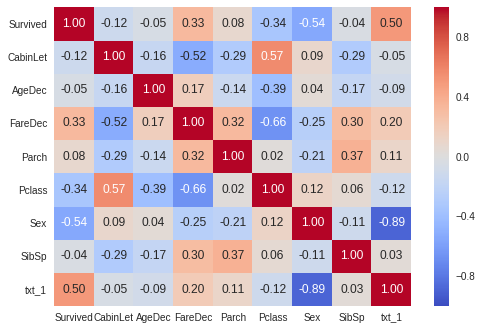

In [6]:
from sklearn.preprocessing import LabelEncoder
   
for c in ['Sex', 'CabinLet']:
        lbl = LabelEncoder()
        lbl.fit(list(traint[c].values))
        traint[c] = lbl.transform(list(traint[c].values))
        
# Correlation matrix between numerical values (SibSp Parch Age and Fare values) and Survived 
g = sns.heatmap(traint[["Survived","CabinLet",'AgeDec',"FareDec","Parch","Pclass",'Sex','SibSp','txt_1']].corr(),annot=True, fmt = ".2f", cmap = "coolwarm")

In [7]:
def add_new_col(x):
    if x not in new_col.keys(): 
        # set n/2 x if is contained in test, but not in train 
        # (n is the number of unique labels in train)
        # or an alternative could be -100 (something out of range [0; n-1]
        return int(len(new_col.keys())/2)
    return new_col[x] # rank of the label



def clust(x):
    kl=0
    if x<0.4:
        kl=1
    if x>0.4 and x<.7:
        kl=2
    if x>.70:
        kl=4
    return kl


new_col4= traint[['Survived','AgeDec']].groupby('AgeDec').describe().fillna(method='bfill')
new_col4.columns=['count','mean','std','min','p25','p50','p75','max']
new_col4['eff']=new_col4['std']/new_col4['mean']
new_col4['eff2']=new_col4['eff']*new_col4['std']
new_col4['clust']=new_col4['eff2'].map(clust)
print(new_col4)

new_col3= traint[['Survived','Pclass']].groupby('Pclass').describe().fillna(method='bfill')
new_col3.columns=['count','mean','std','min','p25','p50','p75','max']
new_col3['eff']=new_col3['std']/new_col3['mean']
new_col3['eff2']=new_col3['eff']*new_col3['std']
new_col3['clust']=new_col3['eff2'].map(clust)
print(new_col3)

new_col2= traint[['Survived','Sex']].groupby('Sex').describe().fillna(method='bfill')
new_col2.columns=['count','mean','std','min','p25','p50','p75','max']
new_col2['eff']=new_col2['std']/new_col2['mean']
new_col2['eff2']=new_col2['eff']*new_col2['std']
new_col2['clust']=new_col2['eff2'].map(clust)
print(new_col2)


new_col= traint[['Survived','CabinLet']].groupby('CabinLet').describe().fillna(method='bfill')
new_col.columns=['count','mean','std','min','p25','p50','p75','max']
new_col['eff']=new_col['std']/new_col['mean']
new_col['eff2']=new_col['eff']*new_col['std']
new_col['clust']=new_col['eff2'].map(clust)
print(new_col)

new_col5= traint[['Survived','FareDec']].groupby('FareDec').describe().fillna(method='bfill')
new_col5.columns=['count','mean','std','min','p25','p50','p75','max']
new_col5['eff']=new_col5['std']/new_col5['mean']
new_col5['eff2']=new_col5['eff']*new_col5['std']
new_col5['clust']=new_col5['eff2'].map(clust)
print(new_col5)

        count      mean       std  min  p25  p50  p75  max       eff  \
AgeDec                                                                 
0.0      48.0  0.645833  0.483321  0.0  0.0  1.0  1.0  1.0  0.748368   
1.0      39.0  0.384615  0.492864  0.0  0.0  0.0  1.0  1.0  1.281447   
2.0     284.0  0.334507  0.472651  0.0  0.0  0.0  1.0  1.0  1.412977   
3.0     230.0  0.400000  0.490966  0.0  0.0  0.0  1.0  1.0  1.227416   
4.0     161.0  0.385093  0.488136  0.0  0.0  0.0  1.0  1.0  1.267578   
5.0      81.0  0.370370  0.485913  0.0  0.0  0.0  1.0  1.0  1.311964   
6.0      40.0  0.400000  0.496139  0.0  0.0  0.0  1.0  1.0  1.240347   
7.0       7.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0       NaN   
8.0       1.0  1.000000       NaN  1.0  1.0  1.0  1.0  1.0       NaN   

            eff2  clust  
AgeDec                   
0.0     0.361702      1  
1.0     0.631579      2  
2.0     0.667845      2  
3.0     0.602620      2  
4.0     0.618750      2  
5.0     0.637500      2  

In [8]:
traint=pd.merge(traint,new_col, how='outer', left_on='CabinLet',suffixes=('', '_c'), right_index=True)
traint=pd.merge(traint,new_col2, how='outer', left_on='Sex',suffixes=('', '_s'), right_index=True)
traint=pd.merge(traint,new_col3, how='outer', left_on='Pclass',suffixes=('', '_p'), right_index=True)
traint=pd.merge(traint,new_col4, how='outer', left_on='AgeDec',suffixes=('', '_a'), right_index=True)
traint=pd.merge(traint,new_col5, how='outer', left_on='FareDec',suffixes=('', '_f'), right_index=True)
#append the Cabinet Letter survival stat

In [9]:
Outliers_to_drop = detect_outliers(traint,2,['Age','SibSp','Parch','Fare','FareDec','AgeDec'])
traint.loc[Outliers_to_drop] # Show the outliers rows
dup_cols=['p25_s', 'min_p', 'p25_p', 'p75_s', 'max_p', 'p25_a', 'max_a']
const_cols=['min_s', 'p25_s', 'max_s', 'min_p', 'p25_p', 'max_p']

Categorical columns: ['Cabin', 'Embarked', 'Name', 'Ticket', 'tekst']
Dublicates: ['p25_s', 'min_p', 'p25_p', 'p75_s', 'max_p', 'p25_a', 'max_a']
Constant cols: ['min_s', 'p25_s', 'max_s', 'min_p', 'p25_p', 'max_p']


/opt/conda/lib/python3.6/site-packages/numpy/lib/function_base.py:4269: RuntimeWarning: Invalid value encountered in percentile
  interpolation=interpolation)


In [10]:
df_new = traint.drop(['tekst','Cabin', 'Embarked', 'Name', 'Sex', 'Ticket', 'CabinLet','p25_s', 'min_p','p25_p', 'p75_s', 'max_p', 'p25_a', 'max_a','min_s', 'p25_s', 'max_s', 'min_p', 'p25_p', 'max_p'], axis=1)
Outliers_to_drop = detect_outliers(df_new,2,['Age','SibSp','Parch','Fare','FareDec','AgeDec'])
#df_new=df_new.sort_values('PassengerId')
#df_new=df_new[df_new['split']==0]  #take the train set again apart


Categorical columns: []
Dublicates: []
Constant cols: []


/opt/conda/lib/python3.6/site-packages/numpy/lib/function_base.py:4269: RuntimeWarning: Invalid value encountered in percentile
  interpolation=interpolation)


In [11]:
print(df_new.describe().T)


           count        mean         std         min         25%         50%  \
Age       1046.0   29.881138   14.413493    0.170000   21.000000   28.000000   
Fare      1308.0   33.295479   51.758668    0.000000    7.895800   14.454200   
Parch     1309.0    0.385027    0.865560    0.000000    0.000000    0.000000   
Pclass    1309.0    2.294882    0.837836    1.000000    2.000000    3.000000   
SibSp     1309.0    0.498854    1.041658    0.000000    0.000000    0.000000   
Survived   891.0    0.383838    0.486592    0.000000    0.000000    0.000000   
split     1309.0    0.319328    0.466394    0.000000    0.000000    0.000000   
AgeDec    1309.0    2.979374    1.427783    0.000000    2.000000    3.000000   
FareDec   1308.0    2.892202    1.019999    0.000000    2.000000    3.000000   
txt_1     1309.0    0.302806    0.273788   -0.000273    0.068523    0.215070   
txt_2     1309.0    0.085211    0.285704   -0.589762   -0.003004    0.105317   
txt_3     1309.0    0.033235    0.226849

In [12]:
def dddraw(X_reduced,name):
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    # To getter a better understanding of interaction of the dimensions
    # plot the first three PCA dimensions
    fig = plt.figure(1, figsize=(8, 6))
    ax = Axes3D(fig, elev=-150, azim=110)
    ax.scatter(X_reduced[:, 0], X_reduced[:, 1], X_reduced[:, 2], c=Y,cmap=plt.cm.Paired)
    titel="First three directions of "+name 
    ax.set_title(titel)
    ax.set_xlabel("1st eigenvector")
    ax.w_xaxis.set_ticklabels([])
    ax.set_ylabel("2nd eigenvector")
    ax.w_yaxis.set_ticklabels([])
    ax.set_zlabel("3rd eigenvector")
    ax.w_zaxis.set_ticklabels([])

    plt.show()

In [13]:
from sklearn.linear_model import OrthogonalMatchingPursuit,RANSACRegressor,LogisticRegression,ElasticNetCV,HuberRegressor, Ridge, Lasso,LassoCV,Lars,BayesianRidge,SGDClassifier,LogisticRegressionCV,RidgeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler,PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

param_grid = {'C': [0.1,1, 10, 100, 1000], 'gamma': [1,0.1,0.01,0.001,0.0001], 'kernel': ['rbf']}

    
# import some data to play with
X = df_new[df_new['split']==0]
X = X.drop(['Survived'],axis=1)
def rmsle(y_predicted, y_real):
    return np.sqrt(np.mean(np.power(np.log1p(y_predicted)-np.log1p(y_real), 2)))
def procenterror(y_predicted, y_real):
     return np.round( np.mean(np.abs(y_predicted-y_real) )/ np.mean(y_real) *100 ,1)

Y=df_new[df_new['split']==0]
Y=Y['Survived']

X=X.replace([np.inf, -np.inf], np.nan).fillna(value=0)
#print(X) #nasty NaN
scaler = MinMaxScaler()
scaler.fit(X)
X=scaler.transform(X)
poly = PolynomialFeatures(2)
X=poly.fit_transform(X)


names = [
         #'ElasticNet',
         'SVC',
         'kSVC',
         'KNN',
         'DecisionTree',
         'RandomForestClassifier',
         #'GridSearchCV',
         'HuberRegressor',
         'Ridge',
         'Lasso',
         'LassoCV',
         'Lars',
         #'BayesianRidge',
         'SGDClassifier',
         'RidgeClassifier',
         'LogisticRegression',
         'OrthogonalMatchingPursuit',
         #'RANSACRegressor',
         ]

classifiers = [
    #ElasticNetCV(cv=10, random_state=0),
    SVC(),
    SVC(kernel = 'rbf', random_state = 0),
    KNeighborsClassifier(n_neighbors = 1),
    DecisionTreeClassifier(),
    RandomForestClassifier(n_estimators = 200),
    #GridSearchCV(SVC(),param_grid, refit = True, verbose = 1),
    HuberRegressor(fit_intercept=True, alpha=0.0, max_iter=100,epsilon=2.95),
    Ridge(fit_intercept=True, alpha=0.0, random_state=0, normalize=True),
    Lasso(alpha=0.05),
    LassoCV(),
    Lars(n_nonzero_coefs=10),
    #BayesianRidge(),
    SGDClassifier(),
    RidgeClassifier(),
    LogisticRegression(),
    OrthogonalMatchingPursuit(),
    #RANSACRegressor(),
]
correction= [0,0,0,0,0,0,0,0,0,0,0,0]

temp=zip(names,classifiers,correction)
print(temp)

for name, clf,correct in temp:
    regr=clf.fit(X,Y)
    #print( name,'% errors', abs(regr.predict(X)+correct-Y).sum()/(Y.sum())*100)
    print(name,'%error',procenterror(regr.predict(X),Y),'rmsle',rmsle(regr.predict(X),Y))
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score, precision_score, recall_score

    # Confusion Matrix
    print(name,'Confusion Matrix')
    print(confusion_matrix(Y, np.round(regr.predict(X) ) ) )
    print('--'*40)

    # Classification Report
    print('Classification Report')
    print(classification_report(Y,np.round( regr.predict(X) ) ))

    # Accuracy
    print('--'*40)
    logreg_accuracy = round(accuracy_score(Y, np.round( regr.predict(X) ) ) * 100,2)
    print('Accuracy', logreg_accuracy,'%')

SVC %error 55.6 rmsle 0.3200835901
SVC Confusion Matrix
[[468  81]
 [109 233]]
--------------------------------------------------------------------------------
Classification Report
             precision    recall  f1-score   support

        0.0       0.81      0.85      0.83       549
        1.0       0.74      0.68      0.71       342

avg / total       0.78      0.79      0.78       891

--------------------------------------------------------------------------------
Accuracy 78.68 %
kSVC %error 55.6 rmsle 0.3200835901
kSVC Confusion Matrix
[[468  81]
 [109 233]]
--------------------------------------------------------------------------------
Classification Report
             precision    recall  f1-score   support

        0.0       0.81      0.85      0.83       549
        1.0       0.74      0.68      0.71       342

avg / total       0.78      0.79      0.78       891

--------------------------------------------------------------------------------
Accuracy 78.68 %
KNN %err

/opt/conda/lib/python3.6/site-packages/scipy/linalg/basic.py:223: RuntimeWarning: scipy.linalg.solve
Ill-conditioned matrix detected. Result is not guaranteed to be accurate.
Reciprocal condition number: 8.284291179852989e-20
  ' condition number: {}'.format(rcond), RuntimeWarning)
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:16: RuntimeWarning: invalid value encountered in log1p
  app.launch_new_instance()
/opt/conda/lib/python3.6/site-packages/sklearn/metrics/classification.py:1137: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples.
  'recall', 'true', average, warn_for)


Ridge %error 578.4 rmsle 1.12701420381
Ridge Confusion Matrix
[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  1  1  8 11 21 37 53 69 77 95 66 56 27 14  6  2  0  2  0  1  1  0  0]
 [ 0  0  0  0  0  1  1  9 20 31 29 42 61 53 39 24 12  7  7  4  0  0  1  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 

/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/coordinate_descent.py:491: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Fitting data with very small alpha may cause precision problems.
  ConvergenceWarning)


LassoCV %error 71.3 rmsle 0.250402587553
LassoCV Confusion Matrix
[[512  37]
 [113 229]]
--------------------------------------------------------------------------------
Classification Report
             precision    recall  f1-score   support

        0.0       0.82      0.93      0.87       549
        1.0       0.86      0.67      0.75       342

avg / total       0.84      0.83      0.83       891

--------------------------------------------------------------------------------
Accuracy 83.16 %


/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/least_angle.py:313: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=7.863e-03, with an active set of 4 regressors, and the smallest cholesky pivot element being 7.146e-08. Reduce max_iter or increase eps parameters.
  ConvergenceWarning)


Lars %error 113.0 rmsle 0.317544288176
Lars Confusion Matrix
[[542   7]
 [257  85]]
--------------------------------------------------------------------------------
Classification Report
             precision    recall  f1-score   support

        0.0       0.68      0.99      0.80       549
        1.0       0.92      0.25      0.39       342

avg / total       0.77      0.70      0.65       891

--------------------------------------------------------------------------------
Accuracy 70.37 %
SGDClassifier %error 40.1 rmsle 0.271798397978
SGDClassifier Confusion Matrix
[[529  20]
 [117 225]]
--------------------------------------------------------------------------------
Classification Report
             precision    recall  f1-score   support

        0.0       0.82      0.96      0.89       549
        1.0       0.92      0.66      0.77       342

avg / total       0.86      0.85      0.84       891

--------------------------------------------------------------------------------


/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/stochastic_gradient.py:128: FutureWarning: max_iter and tol parameters have been added in <class 'sklearn.linear_model.stochastic_gradient.SGDClassifier'> in 0.19. If both are left unset, they default to max_iter=5 and tol=None. If tol is not None, max_iter defaults to max_iter=1000. From 0.21, default max_iter will be 1000, and default tol will be 1e-3.
  "and default tol will be 1e-3." % type(self), FutureWarning)


RidgeClassifier %error 23.4 rmsle 0.207697659467
RidgeClassifier Confusion Matrix
[[522  27]
 [ 53 289]]
--------------------------------------------------------------------------------
Classification Report
             precision    recall  f1-score   support

        0.0       0.91      0.95      0.93       549
        1.0       0.91      0.85      0.88       342

avg / total       0.91      0.91      0.91       891

--------------------------------------------------------------------------------
Accuracy 91.02 %
